# **1. Introduction to the real-world problem**


# Dataset description
## 1. Introducción al problema real

### Descripción del dataset

Para este proyecto se seleccionó el Dry Bean Dataset, un conjunto de datos público utilizado para tareas de clasificación multiclase. Este dataset pertenece al dominio de la agricultura, ya que contiene información relacionada con diferentes tipos de frijoles secos.

Cada observación del dataset representa una muestra de frijol descrita mediante variables predictoras numéricas que capturan propiedades geométricas y de forma, tales como:

- área,
- perímetro,
- longitud del eje mayor,
- longitud del eje menor,
- relación de aspecto,
- excentricidad,
- área convexa,
- diámetro equivalente,
- extensión,
- solidez,
- redondez,
- compacidad,
- factores de forma.

La variable objetivo es Class, la cual indica el tipo de frijol al que pertenece cada muestra. En este problema se tienen siete clases, por lo que se trata de una tarea de clasificación multiclase.



# Data cleaning


Se realizó una inspección inicial del dataset para identificar valores faltantes, inconsistencias y posibles duplicados. A partir del análisis, se observó que el conjunto de datos no contiene valores nulos, lo que indica que no es necesario aplicar técnicas de imputación.

Se encontraron registros duplicados, por lo que fue necesario eliminar observaciones. Esto garantiza que el dataset es consistente y adecuado para el entrenamiento del modelo.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Convertir a DataFrame de Pandas
df = pd.read_excel('/content/Dry_Bean_Dataset.xlsx')


encoder = LabelEncoder()
df["Class"] = encoder.fit_transform(df["Class"])


# Validación de datos y manejo de valores faltantes
# Conteo por columna y suma de todas las columnas.
if df.isnull().sum().sum():
    print("Existen valores faltantes en el dataset.")
else:
    print("No existen valores faltantes en el dataset.")

if df.duplicated().sum().sum():
    print("Existen valores duplicados en el dataset.")
else:
    print("No existen valores duplicados en el dataset.")

No existen valores faltantes en el dataset.
Existen valores duplicados en el dataset.


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicados:", duplicates)

Duplicados: 68


No hay muchos valores duplicados, podemos eliminarlos.

In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,3
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,3
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,3
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,3


Al visualizar el dataset, se observa que cada fila representa una muestra individual de frijol seco, mientras que cada columna corresponde a una característica geométrica o de forma extraída de la imagen del frijol.

Las variables predictoras incluyen medidas como área, perímetro, longitudes de ejes, redondez, compacidad y distintos factores de forma. Estas características permiten describir cuantitativamente la geometría de cada muestra y son utilizadas como entrada para el modelo de clasificación.

La columna Class corresponde a la variable objetivo, es decir, la categoría o tipo de frijol al que pertenece cada muestra. Para facilitar el entrenamiento del modelo, esta variable fue codificada a valores enteros.

.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  int64  
dtypes: float64(14), i

La función `df.info()` permitió verificar la estructura general del dataset. Después de la eliminación de registros duplicados, el conjunto de datos quedó conformado por 13,543 observaciones y 17 columnas.

Se confirmó que todas las variables contienen 13,543 valores no nulos, lo que indica que no existen valores faltantes en ninguna columna.

Además, se observó que todas las variables predictoras son de tipo numérico (`int64` o `float64`), lo cual es adecuado para el entrenamiento de una red neuronal multicapa. La variable objetivo Class también quedó representada como un valor entero (`int64`) después de aplicar `LabelEncoder`, permitiendo su uso en un problema de clasificación multiclase.

En conjunto, esta revisión confirma que el dataset se encuentra en condiciones apropiadas para el modelado.

# Exploratory Data Analysis

In [ ]:
df['Class'].value_counts()

,count
Class,
3,3546
6,2636
5,2027
4,1860
2,1630
0,1322
1,522


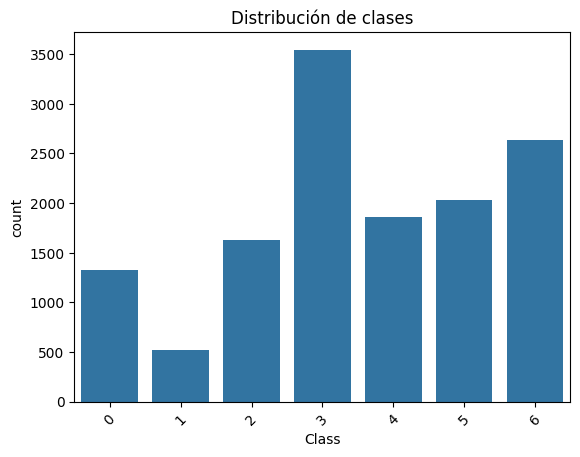

In [ ]:
sns.countplot(x="Class", data=df)
plt.title("Distribución de clases")
plt.xticks(rotation=45)
plt.show()

### Distribución de clases
Los resultados muestran que el dataset no está balanceado, ya que algunas clases contienen significativamente más observaciones que otras. Por ejemplo, la Clase 3 cuenta con 3546 muestras, mientras que la Clase 1 únicamente contiene 522 muestras.

Esto indica que existe una diferencia importante en la representación de las clases dentro del conjunto de datos. Este tipo de desbalance puede influir en el entrenamiento del modelo, ya que la red neuronal podría aprender con mayor facilidad las clases más representadas y presentar más dificultad para clasificar correctamente las clases minoritarias.

Debido a esto, no es suficiente evaluar el modelo únicamente con accuracy. También es importante considerar métricas complementarias como precision, recall, F1-score, specificity y la matriz de confusión, ya que permiten analizar el desempeño del modelo de manera más completa.

In [ ]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078,3.530311
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347,1.832994
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687,0.000000
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720,2.000000
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393,3.000000
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891,5.000000
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733,6.000000


### Estadísticas descriptivas
Las estadísticas muestran que las variables presentan rangos y escalas considerablemente diferentes. Por ejemplo, características como Area, ConvexArea y Perimeter manejan valores mucho más grandes que variables como ShapeFactor2, ShapeFactor3 o ShapeFactor4.

Esta diferencia de escala es importante porque puede afectar el entrenamiento de la red neuronal, ya que variables con magnitudes mayores podrían dominar el proceso de aprendizaje. Debido a ello, fue necesario aplicar una estandarización antes del entrenamiento del modelo.

Finalmente, aunque la columna Class aparece dentro de las estadísticas descriptivas, sus valores no deben interpretarse como una variable continua, ya que corresponden únicamente a etiquetas numéricas asignadas a cada categoría.

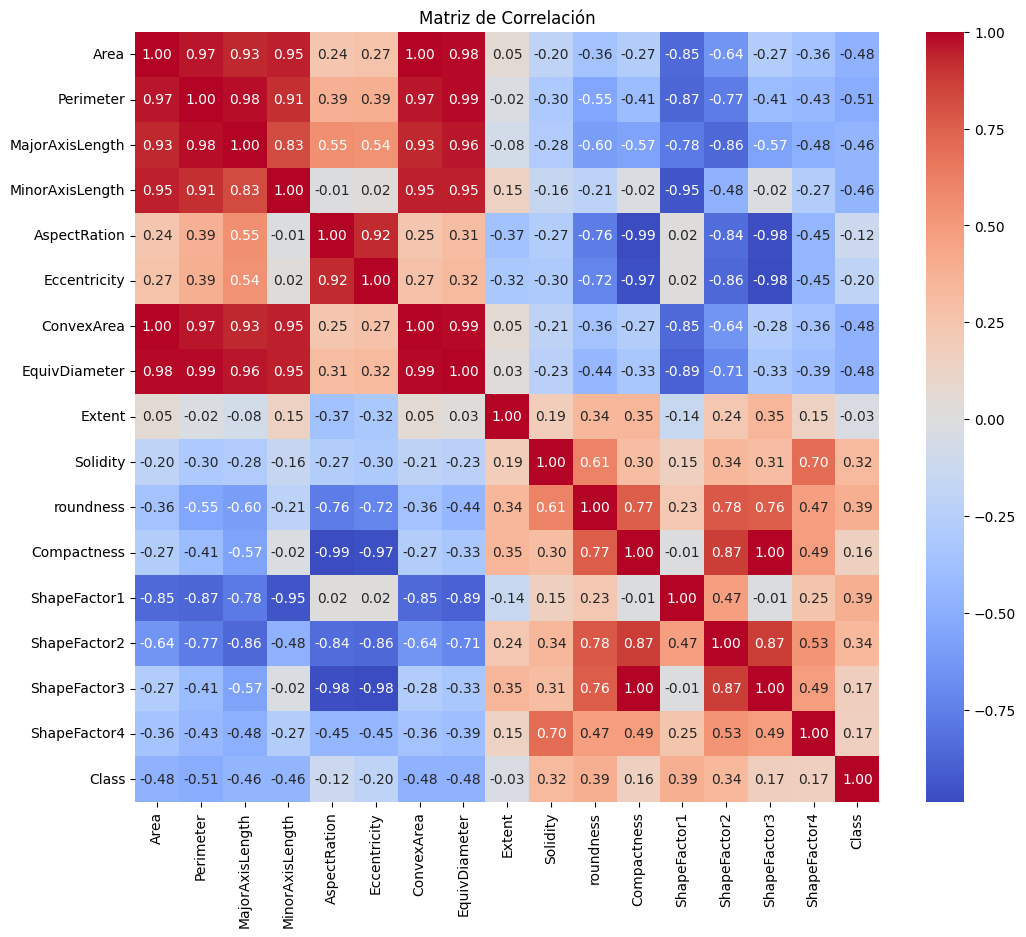

In [ ]:
# Análisis de correlación entre las variables para identificar posibles relaciones
correlation_matrix = df.iloc[:, 0:17].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

x

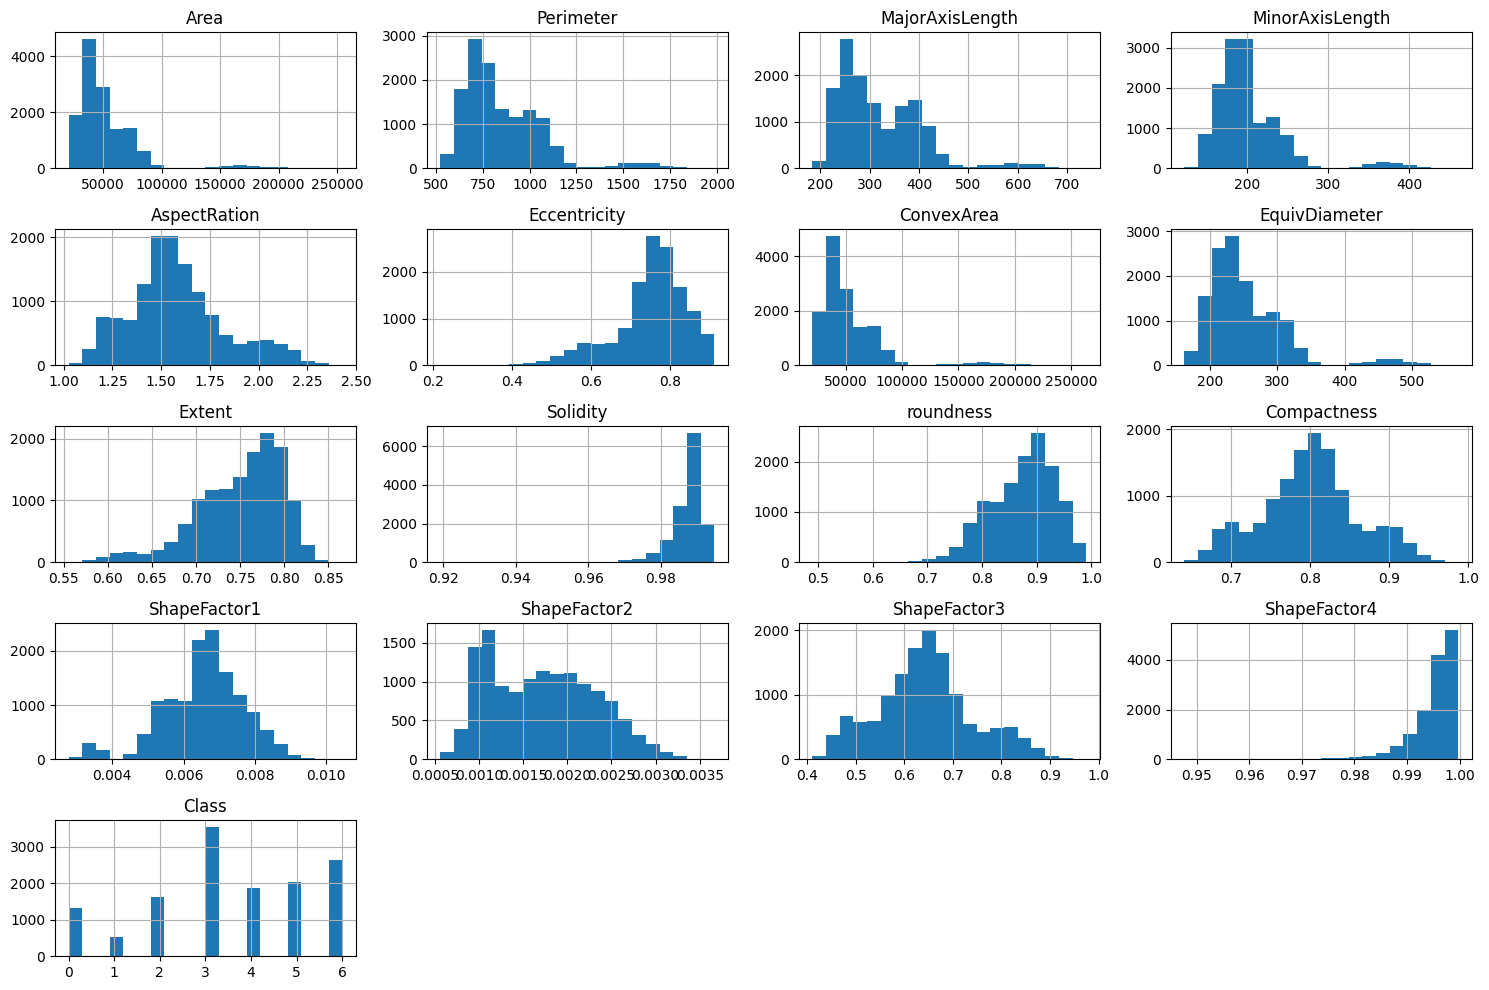

In [ ]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

x

# **2. Design and Training of the Multilayer Neural Network**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.5 MB/s eta 0:00:00


In [ ]:
# Importar librerías para la construcción del modelo de red neuronal
import plotly.express as px
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
import optuna
from tensorflow import keras
from tensorflow.keras import layers

Para entrenar y optimizar el modelo los datos se van a separar en 70% de entrenamiento, 15% para la validacion de la optimización y 15% de prueba para el modelo.

In [ ]:
tf.random.set_seed(4500)
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_t_v, y_train, y_t_v = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_t_v, y_t_v, test_size=0.5, random_state=42)

In [ ]:
# Estandarización de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

Para esta etapa, se definieron primero las variables predictoras y la variable objetivo. Las características de entrada se almacenaron en `X`, mientras que la columna `Class` se utilizó como variable de salida `y`.

Posteriormente, el dataset se dividió en tres subconjuntos:
- **70%** para entrenamiento,
- **15%** para validación,
- **15%** para prueba.

Esta división permite entrenar el modelo, monitorear su desempeño durante el proceso de aprendizaje y finalmente evaluar su capacidad de generalización con datos no vistos.

### Estandarización de características

Antes del entrenamiento, se aplicó una estandarización a las variables predictoras mediante `StandardScaler`. Esto fue necesario debido a que las características del dataset presentan escalas muy diferentes, por ejemplo, algunas variables tienen valores del orden de decenas de miles, mientras que otras son decimales muy pequeños.

La estandarización se ajustó únicamente con el conjunto de entrenamiento y posteriormente se aplicó al conjunto de validación y prueba, con el fin de evitar fuga de información.


In [ ]:
# Modelo base
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(64, activation='relu'),
    layers.Dense(16, activation='relu'),

    layers.Dense(7, activation='softmax')


])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247 (8.78 KB)

 Trainable params: 2,247 (8.78 KB)

 Non-trainable params: 0 (0.00 B)


### Arquitectura del modelo base

Se diseñó un modelo base de red neuronal multicapa utilizando la API `Sequential` de Keras. La arquitectura inicial estuvo compuesta por:

- una capa de entrada con 16 variables,
- una primera capa oculta con 64 neuronas y función de activación ReLU,
- una segunda capa oculta con 16 neuronas y función de activación ReLU,
- y una capa de salida con 7 neuronas y activación Softmax.

La activación ReLU se utilizó en las capas ocultas porque permite aprender relaciones no lineales de forma eficiente, mientras que Softmax es adecuada para un problema de clasificación multiclase, ya que transforma la salida en probabilidades para cada clase.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8247 - loss: 0.5440 - val_accuracy: 0.9060 - val_loss: 0.2713
Epoch 2/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9198 - loss: 0.2319 - val_accuracy: 0.9119 - val_loss: 0.2394
Epoch 3/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9244 - loss: 0.2101 - val_accuracy: 0.9158 - val_loss: 0.2294
Epoch 4/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9256 - loss: 0.2009 - val_accuracy: 0.9178 - val_loss: 0.2255
Epoch 5/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9275 - loss: 0.1955 - val_accuracy: 0.9173 - val_loss: 0.2232
Epoch 6/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9286 - loss: 0.1917 - val_accuracy: 0.9183 - val_loss: 0.2218
Epoch 7/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9280 - loss: 0.1887 - val_accuracy: 0.9178 - val_loss: 0.2209
Epoch 8/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9290 - loss: 0.1865 - val_accu



### Función de pérdida y optimizador

El modelo se compiló utilizando:
- el optimizador Adam,
- una tasa de aprendizaje de 0.001,
- la función de pérdida sparse categorical crossentropy,
- y la métrica accuracy.

La función de pérdida seleccionada es apropiada porque la variable objetivo fue codificada como enteros y el problema consiste en clasificar observaciones en una de siete clases posibles.

### Entrenamiento del modelo

El modelo fue entrenado con un máximo de 100 épocas y un batch size de 16. Además, se incorporó la técnica de Early Stopping, monitoreando la pérdida de validación (`val_loss`) con una paciencia de 5 épocas y restaurando automáticamente los mejores pesos obtenidos.

Este procedimiento permitió detener el entrenamiento cuando el modelo dejó de mejorar en validación, evitando así un entrenamiento innecesario y reduciendo el riesgo de sobreajuste.

# Optimización de Hiperparámetros

In [ ]:
def objective(trial):

    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    num_layers = trial.suggest_int("num_layers", 2, 4)

    model = tf.keras.Sequential()

    # Capa de entrada
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    # Capas ocultas
    for i in range(num_layers):
        units = trial.suggest_int(f"units_l{i}", 16, 512)
        model.add(tf.keras.layers.Dense(units, activation='relu'))

    # Capa de salida
    model.add(tf.keras.layers.Dense(7, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Retornamos el mejor accuracy de validación
    return max(history.history['val_accuracy'])

In [ ]:
# 3. Ejecución de la Optimización
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

# 4. Guardar y evaluar el mejor modelo
print(f"Mejor configuración: {study.best_params}")

[I 2026-03-26 03:47:12,073] A new study created in memory with name: no-name-706727b0-39c0-4e07-8d85-2bcfee2947bb
[I 2026-03-26 03:47:44,623] Trial 0 finished with value: 0.9217519760131836 and parameters: {'learning_rate': 0.00684550594507774, 'batch_size': 32, 'num_layers': 3, 'units_l0': 354, 'units_l1': 394, 'units_l2': 231}. Best is trial 0 with value: 0.9217519760131836.
[I 2026-03-26 03:49:13,032] Trial 1 finished with value: 0.9187992215156555 and parameters: {'learning_rate': 0.00014218045015090906, 'batch_size': 16, 'num_layers': 3, 'units_l0': 25, 'units_l1': 224, 'units_l2': 163}. Best is trial 0 with value: 0.9217519760131836.
[I 2026-03-26 03:49:54,747] Trial 2 finished with value: 0.9266732335090637 and parameters: {'learning_rate': 0.0021815641038962262, 'batch_size': 16, 'num_layers': 2, 'units_l0': 477, 'units_l1': 448}. Best is trial 2 with value: 0.9266732335090637.
[I 2026-03-26 03:50:36,780] Trial 3 finished with value: 0.9247047305107117 and parameters: {'learnin

Mejor configuración: {'learning_rate': 0.0003679496739086954, 'batch_size': 16, 'num_layers': 2, 'units_l0': 464, 'units_l1': 466}


In [ ]:
# Extraer los mejores hiperparámetros encontrados por Optuna
best_params = study.best_params

print("Mejores hiperparámetros encontrados:")
print(best_params)

# Construir el modelo final con los mejores hiperparámetros
best_model = keras.Sequential()
best_model.add(layers.Input(shape=(X_train.shape[1],)))

for i in range(best_params["num_layers"]):
    best_model.add(
        layers.Dense(best_params[f"units_l{i}"], activation='relu')
    )

best_model.add(layers.Dense(7, activation='softmax'))

# Compilar el modelo
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
best_model.summary()

Mejores hiperparámetros encontrados:
{'learning_rate': 0.0003679496739086954, 'batch_size': 16, 'num_layers': 2, 'units_l0': 464, 'units_l1': 466}


Model: "sequential_59"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_234 (Dense)               │ (None, 464)            │         7,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_235 (Dense)               │ (None, 466)            │       216,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_236 (Dense)               │ (None, 7)              │         3,269 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,847 (890.03 KB)

 Trainable params: 227,847 (890.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_best = best_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=best_params["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8928 - loss: 0.3221 - val_accuracy: 0.9149 - val_loss: 0.2341
Epoch 2/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9216 - loss: 0.2090 - val_accuracy: 0.9149 - val_loss: 0.2251
Epoch 3/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9256 - loss: 0.1987 - val_accuracy: 0.9163 - val_loss: 0.2220
Epoch 4/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9271 - loss: 0.1927 - val_accuracy: 0.9183 - val_loss: 0.2202
Epoch 5/100
593/593 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9287 - loss: 0.1886 - val_accuracy: 0.9183 - val_loss: 0.2194


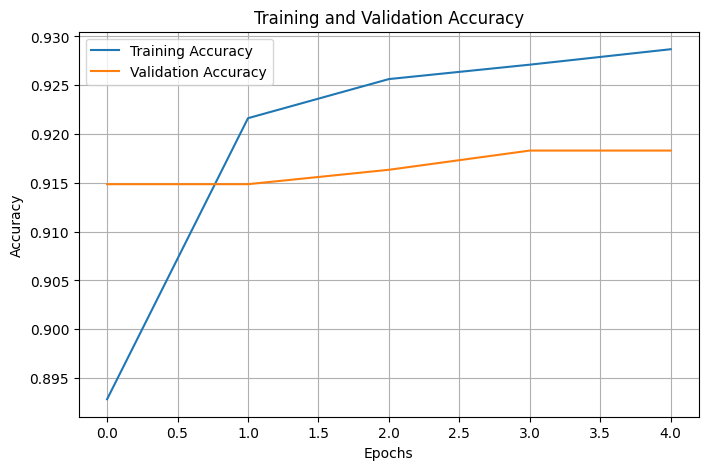

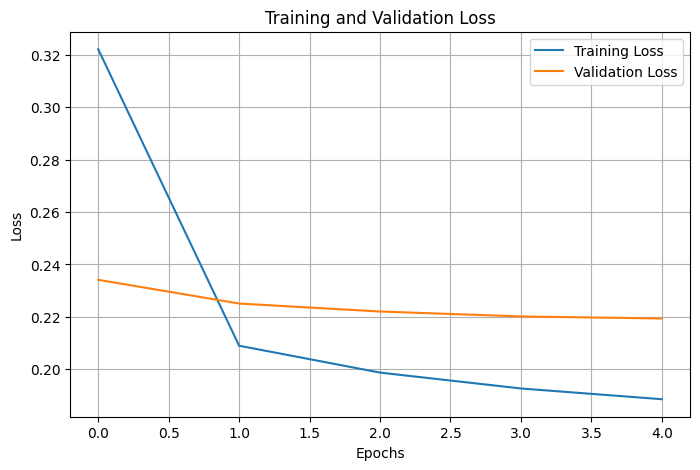

In [ ]:
# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


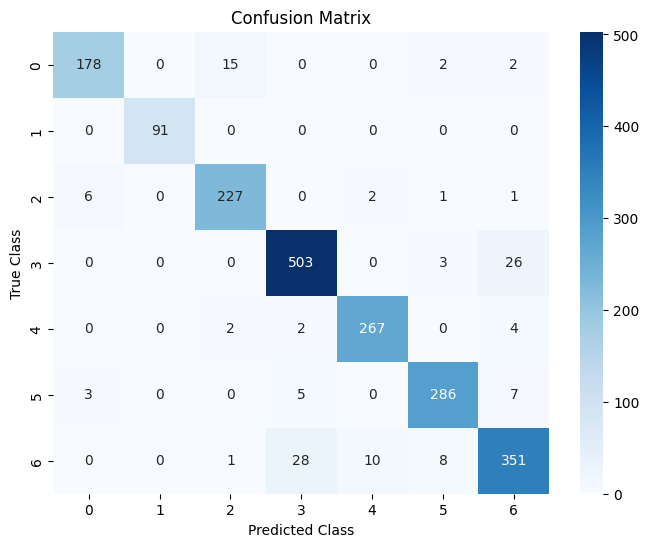

Accuracy: 0.9369768586903003
Precision: 0.9369306105682859
Recall: 0.9369768586903003
F1-score: 0.9368337593379882


In [ ]:
# Predicciones del modelo sobre el conjunto de prueba
y_pred_probs = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# Métricas generales
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

## 6. Evaluación del Modelo con el Conjunto de Prueba

Una vez entrenado el modelo optimizado, se evaluó su desempeño utilizando el conjunto de prueba, el cual contiene datos que no fueron utilizados durante el entrenamiento ni la validación.

Las métricas obtenidas fueron las siguientes:

- **Accuracy:** 0.9370
- **Precision:** 0.9369
- **Recall:** 0.9370
- **F1-score:** 0.9368
- **Specificity promedio:** 0.9889

### Interpretación de las métricas

La accuracy representa el porcentaje total de predicciones correctas realizadas por el modelo. En este caso, el modelo clasificó correctamente aproximadamente el 93.7% de las muestras del conjunto de prueba, lo cual indica un desempeño general muy sólido.

La precision indica qué tan confiables son las predicciones positivas realizadas por el modelo. Un valor alto sugiere que, cuando el modelo asigna una clase, normalmente lo hace de forma correcta.

El recall mide la capacidad del modelo para identificar correctamente las muestras reales de cada clase. Un recall elevado significa que el modelo logra detectar adecuadamente la mayoría de los casos verdaderos.

El F1-score es especialmente importante en este problema debido a que el dataset no está perfectamente balanceado. Esta métrica combina precision y recall en un solo valor, y en este caso confirma que el modelo mantiene un buen equilibrio entre ambas.

La specificity mide qué tan bien el modelo evita clasificar incorrectamente muestras de otras clases como si pertenecieran a una clase determinada. El valor promedio obtenido fue de 98.89%, lo que indica una alta capacidad de discriminación entre clases.

### Interpretación de la matriz de confusión

La matriz de confusión muestra que la mayoría de las predicciones correctas se encuentran sobre la diagonal principal, lo que indica un buen desempeño general del modelo.

Se observa que algunas clases son clasificadas casi perfectamente, mientras que otras presentan pequeñas confusiones. En particular, la Clase 6 tiende a confundirse ocasionalmente con las clases 3, 4 y 5, mientras que la Clase 3 también presenta algunas confusiones con la Clase 6. Esto sugiere que dichas clases comparten características geométricas similares, lo que dificulta ligeramente su separación.

En general, los errores del modelo no son aleatorios, sino que ocurren principalmente entre clases con patrones parecidos, lo cual es completamente esperable en un problema de clasificación multiclase del mundo real.

### Conclusión de desempeño

Con base en las métricas obtenidas y la matriz de confusión, se concluye que el modelo presenta un desempeño aceptable y sólido, mostrando buena capacidad de generalización sobre datos no vistos.

In [ ]:
# Cálculo de specificity por clase y promedio
specificities = []

for i in range(cm.shape[0]):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    specificity = TN / (TN + FP)
    specificities.append(specificity)

print("Specificity por clase:", specificities)
print("Specificity promedio:", np.mean(specificities))

Specificity por clase: [np.float64(0.995092693565976), np.float64(1.0), np.float64(0.9899665551839465), np.float64(0.9766511007338226), np.float64(0.9931662870159453), np.float64(0.991907514450867), np.float64(0.9755052051439069)]
Specificity promedio: 0.9888984794420664


In [ ]:
# Guardar el modelo entrenado
best_model.save("dry_bean_best_model.keras")

print("Modelo guardado correctamente.")

In [ ]:
# Cargar el modelo guardado
loaded_model = load_model("dry_bean_best_model.keras")

print("Modelo cargado correctamente.")
loaded_model.summary()

In [ ]:
# Probar que el modelo cargado funciona correctamente
loaded_predictions = loaded_model.predict(X_test_scaled)
loaded_pred_classes = np.argmax(loaded_predictions, axis=1)

loaded_accuracy = accuracy_score(y_test, loaded_pred_classes)
print("Accuracy del modelo cargado:", loaded_accuracy)

## 8. Conclusiones - Ramón
A lo largo del trabajo fue posible aplicar de forma práctica varias etapas importantes del aprendizaje profundo, desde el análisis y preprocesamiento de los datos hasta el entrenamiento y evaluación final del modelo.

Uno de los principales aprendizajes fue entender que el rendimiento de una red neuronal no depende solo de la arquitectura, sino también de la calidad y preparación de los datos. En este caso, el análisis exploratorio permitió identificar el desbalance entre clases y la diferencia de escala entre variables, lo que justificó la estandarización antes del entrenamiento.

También se observó que el modelo base ya lograba un buen desempeño, pero la optimización de hiperparámetros con Optuna permitió encontrar una configuración más adecuada. Aunque no ayudo mucho a la mejora del modelo, sí ayudó a obtener un modelo más sólido.

Además, el uso de Early Stopping fue útil para evitar entrenamiento innecesario y reducir el riesgo de sobreajuste. Al revisar las curvas de aprendizaje y las métricas finales, se concluye que el modelo logró un buen equilibrio entre aprendizaje y generalización.

En general, esta tarea ayudó a comprender mejor cómo se diseña, entrena y evalúa una red neuronal multicapa en un problema real, y dejó claro que cada decisión tomada durante el proceso influye en el resultado final.

https://github.com/ramonlerma-cr/MNN-HPO-Team9